In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
df= pd.read_csv("Sales_transactions_2022_2025.csv")
df.head()

,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Order_Status,Shipping_Method,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year
0,T02016694,O0116694,C01482,Sophia Smith,28.0,Male,Consumer,2022-10-06,11:30:55,Online,...,Completed,Standard,4.0,No,NaN,James Anderson,SAVE10,4.0,81.0,2022
1,T02016374,O0108187,C01591,Hannah King,46.0,Female,Consumer,2024-06-03,17:06:29,Online,...,Completed,Standard,6.0,No,NaN,Ella Lewis,NaN,5.0,123.0,2024
2,T02004099,O0104099,C04140,Emma Wilson,42.0,Male,Consumer,2024-12-19,08:22:11,Online,...,Shipped,Standard,4.0,No,NaN,Liam Davis,NaN,4.0,93.0,2024
3,T02010280,O0110280,C03663,Daniel Clark,18.0,Male,Corporate,2025-10-05,14:32:43,B2B Portal,...,Completed,Next Day,2.0,No,NaN,Grace Harris,HOLIDAY20,NaN,59.0,2025
4,T02012685,O0112685,C02749,Sophia Smith,37.0,Male,Returning Customer,2022-09-13,14:55:16,B2B Portal,...,Completed,Express,2.0,No,NaN,Sophia Brown,NaN,2.0,56.0,2022


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18045 entries, 0 to 18044
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        18045 non-null  object 
 1   Order_ID              18045 non-null  object 
 2   Customer_ID           18045 non-null  object 
 3   Customer_Name         17937 non-null  object 
 4   Customer_Age          17827 non-null  float64
 5   Customer_Gender       17883 non-null  object 
 6   Customer_Segment      18045 non-null  object 
 7   Order_Date            18045 non-null  object 
 8   Order_Time            18045 non-null  object 
 9   Sales_Channel         18045 non-null  object 
 10  Store_ID              18045 non-null  object 
 11  Store_Name            18045 non-null  object 
 12  Country               18045 non-null  object 
 13  Region                18045 non-null  object 
 14  City                  18045 non-null  object 
 15  Product_ID         

In [4]:
df[["Customer_Name","Customer_Age","Customer_Gender"]]=df.groupby(
    "Customer_ID")[["Customer_Name","Customer_Age","Customer_Gender"]].ffill().groupby(
    df["Customer_ID"]).bfill()

In [5]:
df[["Customer_Name","Customer_Gender"]]=df[["Customer_Name","Customer_Gender"]].fillna("Unknown")
df["Customer_Age"]=df.groupby("Customer_Segment")["Customer_Age"].transform(lambda x:x.fillna(x.median()))

In [6]:
df["Product_Name"]=df.groupby("Product_ID")["Product_Name"].ffill().groupby(df["Product_ID"]).bfill()

In [7]:
df["Payment_Method"]=df["Payment_Method"].fillna("unknown")

In [8]:
df["Delivery_Days"]=df.groupby("Shipping_Method")["Delivery_Days"].transform(
    lambda x:x.fillna(x.median())).round()

In [9]:
df["Return_Reason"]=df["Return_Reason"].fillna("Not Returned")
df.loc[(df["Return_Flag"]=="Yes") & (df["Return_Reason"]=="Not Returned"),"Return_Reason"]="Not Specified"

In [10]:
df["Promotion_Code"]=df["Promotion_Code"].fillna("No Code")

In [11]:
df["Customer_Rating"]=df.groupby("Product_ID")["Customer_Rating"].transform(lambda x:x.fillna(x.mean()))

In [12]:
df["Inventory_Level"]=df.groupby(["Store_ID","Product_ID"])["Inventory_Level"].transform(
    lambda x:x.fillna(x.median()))

In [13]:
df.isnull().sum()

Transaction_ID          0
Order_ID                0
Customer_ID             0
Customer_Name           0
Customer_Age            0
Customer_Gender         0
Customer_Segment        0
Order_Date              0
Order_Time              0
Sales_Channel           0
Store_ID                0
Store_Name              0
Country                 0
Region                  0
City                    0
Product_ID              0
Product_Name            0
Product_Category        0
Product_Subcategory     0
Quantity                0
Unit_Price              0
Discount_Percentage     0
Sales_Amount            0
Cost_Amount             0
Profit                  0
Payment_Method          0
Order_Status            0
Shipping_Method         0
Delivery_Days           0
Return_Flag             0
Return_Reason           0
Sales_Representative    0
Promotion_Code          0
Customer_Rating         0
Inventory_Level         0
Order_Year              0
dtype: int64

In [14]:
df["Payment_Method"]=df["Payment_Method"].replace(
    {"DebitCard":"Debit Card","Bank transfer":"Bank Transfer","credit card":"Credit Card","paypal":"PayPal"})

In [15]:
df["Product_Category"]=df["Product_Category"].replace(
    {"FURNITURE":"Furniture","electronics":"Electronics","Office supplies":"Office Supplies"})

In [16]:
df["Customer_Gender"]=df["Customer_Gender"].replace(
    {"FEMALE":"Female","male":"Male","Non Binary":"Non-binary"})

In [17]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"],format="mixed", errors="coerce")

In [18]:
df["Hour"]=pd.to_datetime(df["Order_Time"],format="mixed", errors="coerce").dt.hour

In [19]:
df["Time_of_Day"]=pd.cut(x=df["Hour"],bins=[-1,4,11,16,20,24],labels=["Night","Morning","Afternoon","Evening","Night"],ordered=False)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.head()

,Transaction_ID,Order_ID,Customer_ID,Customer_Name,Customer_Age,Customer_Gender,Customer_Segment,Order_Date,Order_Time,Sales_Channel,...,Delivery_Days,Return_Flag,Return_Reason,Sales_Representative,Promotion_Code,Customer_Rating,Inventory_Level,Order_Year,Hour,Time_of_Day
0,T02016694,O0116694,C01482,Sophia Smith,28.0,Male,Consumer,2022-10-06,11:30:55,Online,...,4.0,No,Not Returned,James Anderson,SAVE10,4.00,81.0,2022,11,Morning
1,T02016374,O0108187,C01591,Hannah King,46.0,Female,Consumer,2024-06-03,17:06:29,Online,...,6.0,No,Not Returned,Ella Lewis,No Code,5.00,123.0,2024,17,Evening
2,T02004099,O0104099,C04140,Emma Wilson,42.0,Male,Consumer,2024-12-19,08:22:11,Online,...,4.0,No,Not Returned,Liam Davis,No Code,4.00,93.0,2024,8,Morning
3,T02010280,O0110280,C03663,Daniel Clark,18.0,Male,Corporate,2025-10-05,14:32:43,B2B Portal,...,2.0,No,Not Returned,Grace Harris,HOLIDAY20,3.98,59.0,2025,14,Afternoon
4,T02012685,O0112685,C02749,Sophia Smith,37.0,Male,Returning Customer,2022-09-13,14:55:16,B2B Portal,...,2.0,No,Not Returned,Sophia Brown,No Code,2.00,56.0,2022,14,Afternoon


# Country Wise Sales

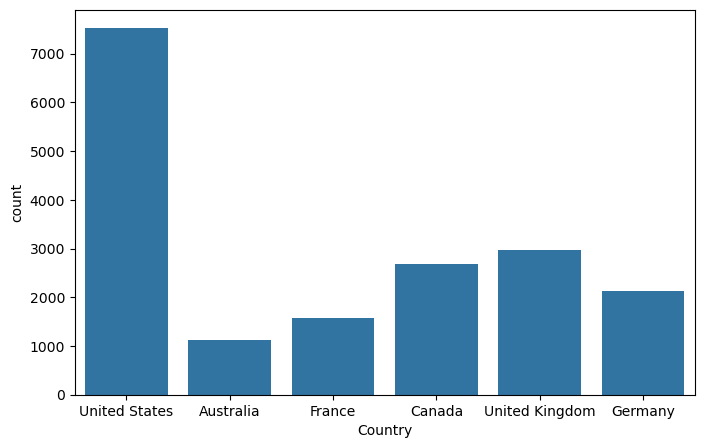

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Country"])
plt.show()

### Conclusion
**United Stated hold majority of sales and Australia has the least**

# Payment Method

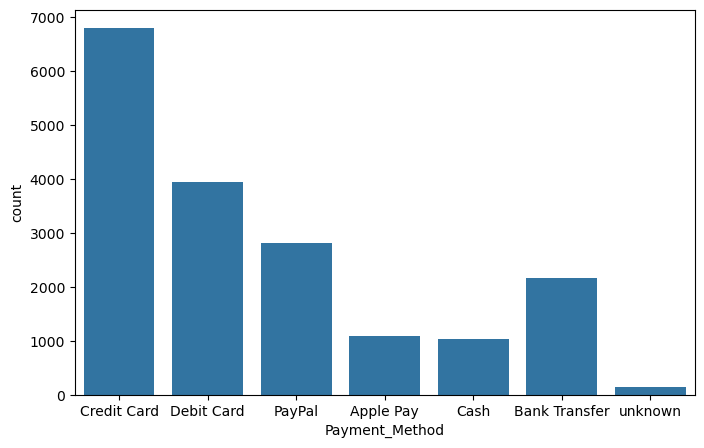

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Payment_Method"])
plt.show()

### Conclusion
**Credit card is the most used payment method followed by Debit Card,Paypal and Bank Transfer**

# Transaction count based on Time of the day

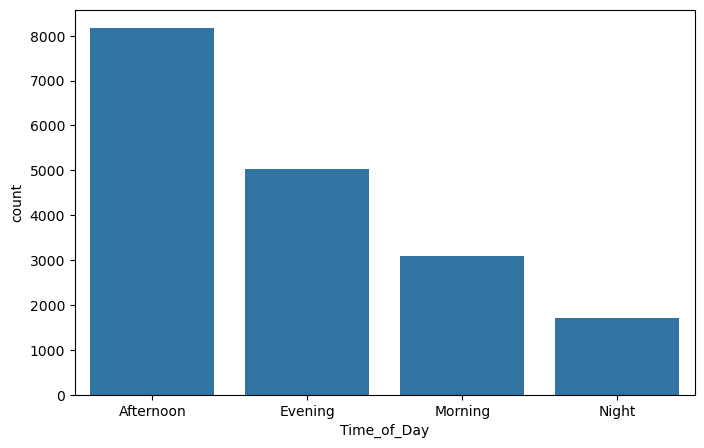

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Time_of_Day"])
plt.show()

### Conclusion
**Majority of sales happened during the afternoon time followed by evening and morning and night is the least**

# Sales Return

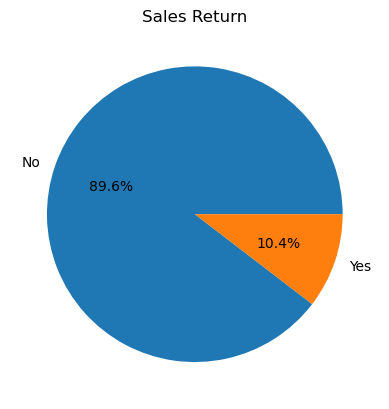

In [26]:
countt=df["Return_Flag"].value_counts()
plt.pie(x=countt,labels=countt.index, autopct="%1.1f%%")
plt.title("Sales Return")
plt.show()

### Conclusion
**There is more than 10% sales return happening, it should be considered**

# Return Reason 

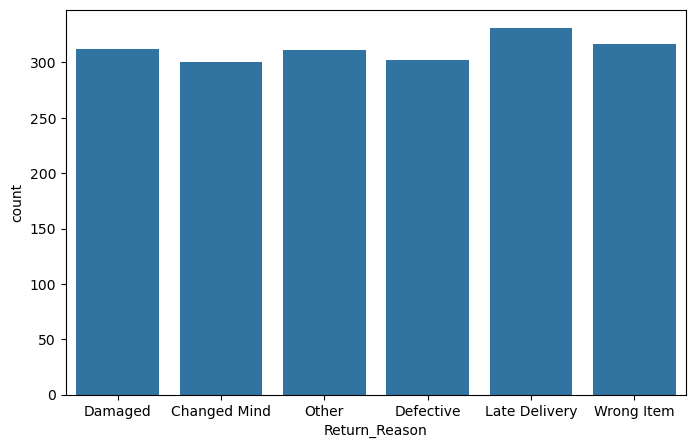

In [27]:
reason=df["Return_Reason"][(df["Return_Reason"]!="Not Returned")]
plt.figure(figsize=(8,5))
sns.countplot(x=reason)
plt.show()

### Conclusion
**All the reason hold almost same level of count, "Late deivery" is the top among them**

# Relation between Shipping method and Sales Return

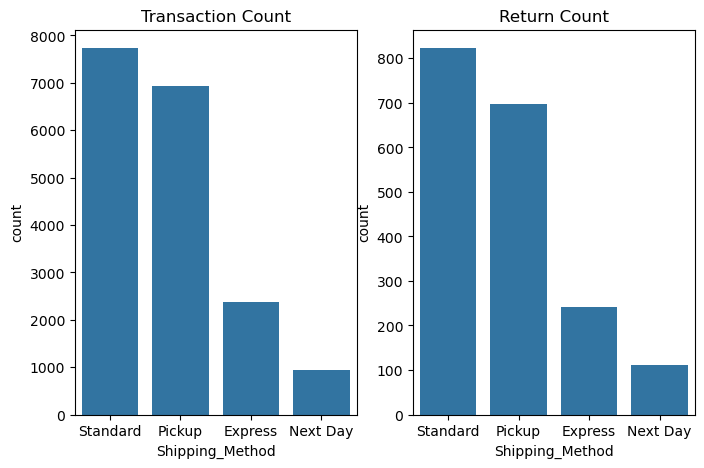

In [28]:
returned=df["Shipping_Method"][(df["Return_Flag"]=="Yes")].reset_index()
plt.figure(figsize=(8,5))

plt.subplot(1,2,1)
sns.countplot(x=df["Shipping_Method"],order=df["Shipping_Method"].value_counts().index)
plt.title("Transaction Count")

plt.subplot(1,2,2)
sns.countplot(x=returned["Shipping_Method"],order=returned["Shipping_Method"].value_counts().index)
plt.title("Return Count")
plt.show()

### Conclusion
**Both Transaction Count and Return Count Follows same Trend amond shipping method so shipping is not affecting Sales Return**

# Sales Among Product Categories

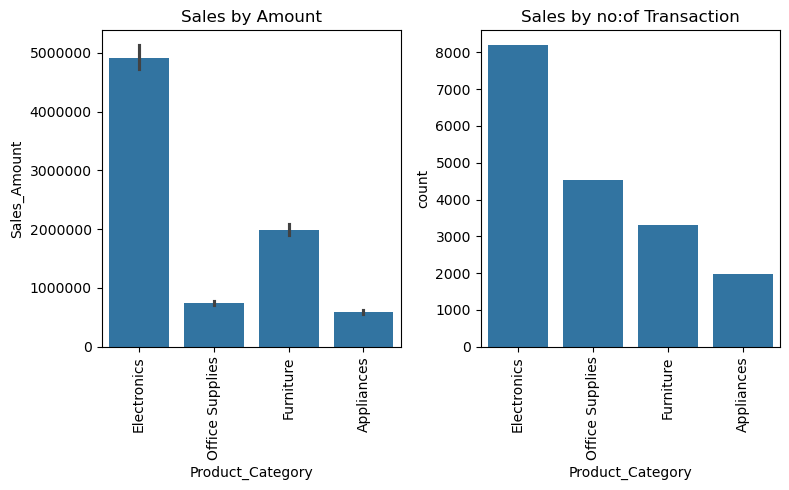

In [29]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
sns.barplot(x=df["Product_Category"], y=df["Sales_Amount"],estimator="sum")
plt.xticks(rotation=90)
plt.ticklabel_format(style="plain",axis="y")
plt.title("Sales by Amount")

plt.subplot(1,2,2)
sns.countplot(x=df["Product_Category"])
plt.xticks(rotation=90)
plt.title("Sales by no:of Transaction")
plt.tight_layout()

plt.show()

### Conclusion
**"Electronics" is the most sold category among all and "Appliance" is the least**

# Profit Among Product Categories

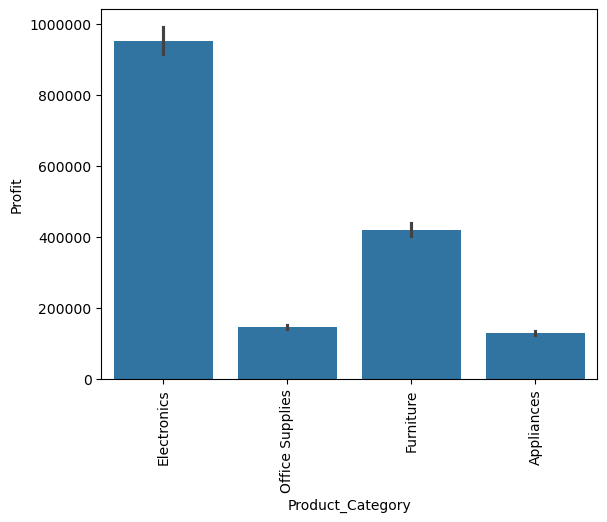

In [30]:
sns.barplot(x=df["Product_Category"], y=df["Profit"],estimator="sum")
plt.xticks(rotation=90)
plt.ticklabel_format(style="plain",axis="y")

### Conclusion
**"Electronics" is the most sold category among all and "Office Supplies" and "Appliance" is the least**

# Transaction Count Based on Customer Gender 

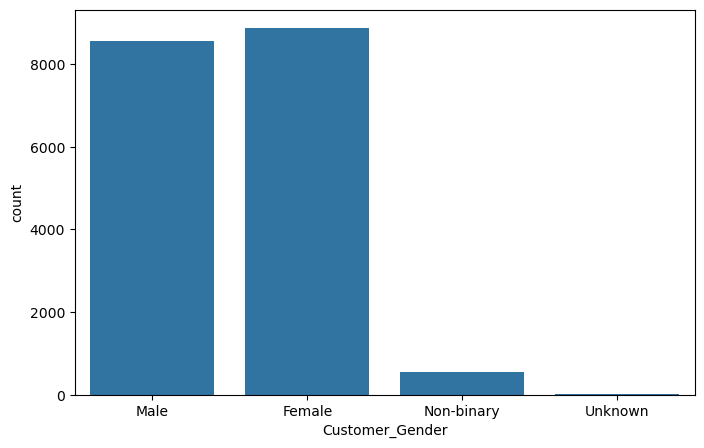

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Customer_Gender"])
plt.show()

### Conclusion
**Majority of the transaction is made by Female followed by male**

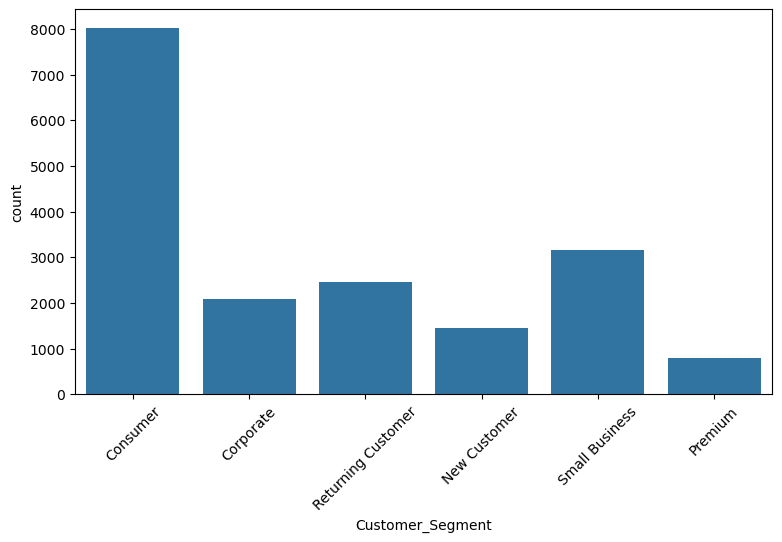

In [32]:
plt.figure(figsize=(9,5))
sns.countplot(x=df["Customer_Segment"])
plt.xticks(rotation=45)
plt.show()

# Transaction Count Based on Sales Channel

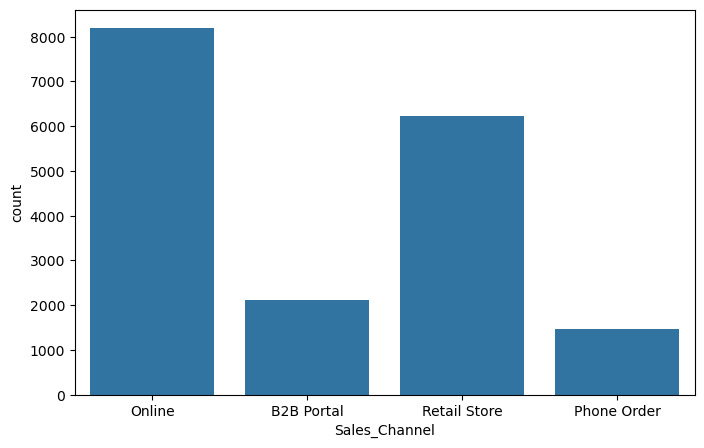

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["Sales_Channel"])
plt.show()

### Conclusion
**Majority of the transaction is made through online sales channel followed by Retail Store**

# Sales Over Year

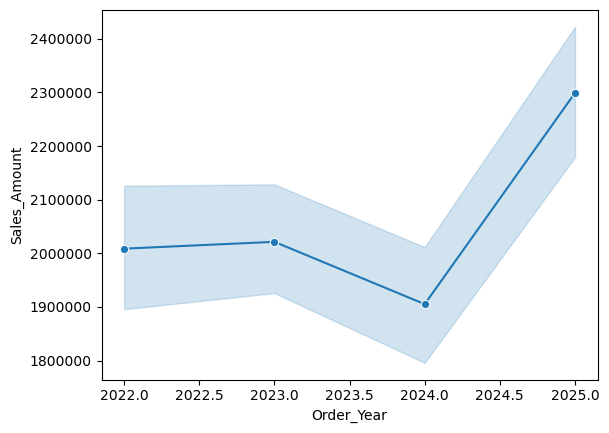

In [34]:
sns.lineplot(data=df,x="Order_Year",y="Sales_Amount",estimator="sum",marker="o" )
plt.ticklabel_format(style="plain",axis="y")
plt.show()

### Conclusion
**Sales comback strongly in 2025 after a big fall in 2024**

# Relationship Between Profit and Discount

In [35]:
from sklearn.preprocessing import MinMaxScaler

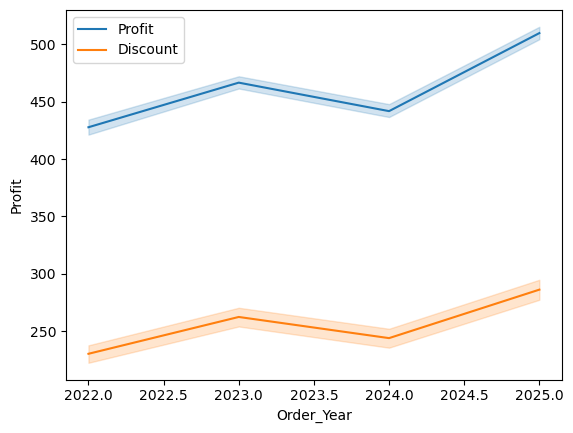

In [36]:
df1=df[["Order_Year","Profit","Discount_Percentage"]].reset_index()
scaler=MinMaxScaler()
df1[["Profit","Discount_Percentage"]]=scaler.fit_transform(df1[["Profit","Discount_Percentage"]])

sns.lineplot(data=df1,x="Order_Year",y="Profit",estimator="sum",markers="o",label="Profit" )
sns.lineplot(data=df1,x="Order_Year",y="Discount_Percentage",estimator="sum",markers="o",label="Discount" )
plt.ticklabel_format(style="plain",axis="y")
plt.show()

[]

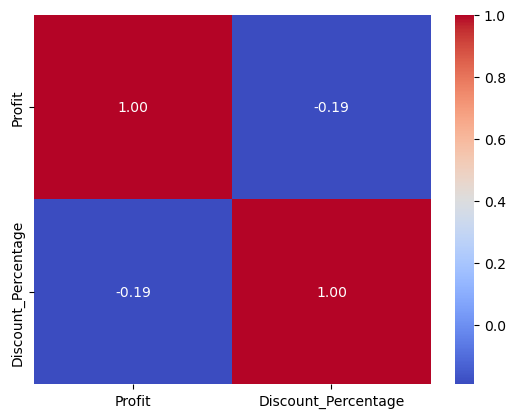

In [37]:
correl=df[["Profit","Discount_Percentage"]].corr()
sns.heatmap(data=correl,annot=True,cmap="coolwarm",fmt="0.2f")
plt.plot()

### Conclusion
**There is a weak negative coorelation between profit and discount indicating higher discount slighly diminishing overall profitability.**

# Export Cleaned Data

In [38]:
df.to_excel("Sales_data.xlsx", index=False)